# Section 4 Optimisation and width in a teacher–student Transformer: an empirical analogue of infinite-width convergence

## Transformer architecture and student-teacher setup

In [ ]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# --------------------------
# Transformer model (1 layer) for scalar regression
# --------------------------
class OneLayerTransformerRegressor(nn.Module):
    def __init__(self, vocab_size, seq_len, d_model, n_heads, d_ff, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.vocab_size = vocab_size
        self.seq_len = seq_len
        self.d_model = d_model

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,   # (B, L, D)
            norm_first=True     # pre-norm tends to be more stable
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=1)

        self.head = nn.Linear(d_model, 1)

    def forward(self, x_tokens):
        """
        x_tokens: LongTensor of shape (B, L)
        returns: FloatTensor of shape (B, 1)
        """
        B, L = x_tokens.shape
        assert L == self.seq_len, "sequence length mismatch"

        h = self.token_emb(x_tokens)                      # (B, L, D)
        h = h + self.pos_emb.unsqueeze(0)                 # (B, L, D)
        h = self.encoder(h)                               # (B, L, D)

        h_pool = h.mean(dim=1)                            # (B, D)  mean-pooling
        out = self.head(h_pool)                           # (B, 1)
        return out

# --------------------------
# Teacher-student dataset for transformer
# --------------------------
@torch.no_grad()
def make_teacher_student_dataset_transformer(
    N=8192,
    seq_len=32,
    vocab_size=128,
    teacher_d_model=64,
    teacher_heads=4,
    teacher_d_ff=256,
    noise_std=0.0,
    seed=0,
    batch_for_teacher=1024
):
    """
    X: token sequences (N, L) int64
    y: teacher scalar outputs (N, 1) float32
    """
    set_seed(seed)

    # Random token sequences
    X = torch.randint(low=0, high=vocab_size, size=(N, seq_len), dtype=torch.long)

    # Build teacher (fixed) and generate targets in batches (GPU-friendly)
    teacher = OneLayerTransformerRegressor(
        vocab_size=vocab_size,
        seq_len=seq_len,
        d_model=teacher_d_model,
        n_heads=teacher_heads,
        d_ff=teacher_d_ff,
        dropout=0.0
    ).to(device)
    teacher.eval()

    ys = []
    for i in range(0, N, batch_for_teacher):
        xb = X[i:i+batch_for_teacher].to(device)
        yb = teacher(xb)  # (b, 1)
        ys.append(yb.detach().cpu())
    y = torch.cat(ys, dim=0)

    if noise_std > 0:
        y = y + noise_std * torch.randn_like(y)

    return X, y, teacher  # returning teacher is optional but sometimes useful

# --------------------------
# Optimizers
# --------------------------
def make_sgd(model, lr=1e-2, momentum=0.9):
    return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)

def make_adam(model, lr=1e-3):
    return torch.optim.Adam(model.parameters(), lr=lr)

def make_muon_hybrid(model, lr=1e-3, wd=0.0):
    """
    Use Muon for 2D parameters (weight matrices),
    and AdamW for 1D parameters (biases, LayerNorm scale, embeddings are 2D so they go to Muon).
    """
    muon_params = []
    other_params = []
    for p in model.parameters():
        if not p.requires_grad:
            continue
        if p.ndim == 2:
            muon_params.append(p)
        else:
            other_params.append(p)

    opt_muon = torch.optim.Muon(muon_params, lr=lr, weight_decay=wd) if muon_params else None
    opt_other = torch.optim.AdamW(other_params, lr=lr, weight_decay=wd) if other_params else None

    opts = []
    if opt_muon is not None: opts.append(opt_muon)
    if opt_other is not None: opts.append(opt_other)
    return opts

# --------------------------
# Training loop
# --------------------------
def train_curve(
    X, y, make_model, make_optimizer,
    epochs=200, batch_size=256, seed_for_init=123,
    verbose=False
):
    set_seed(seed_for_init)
    model = make_model().to(device)

    ds = TensorDataset(X, y)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)

    opts = make_optimizer(model)
    if not isinstance(opts, (list, tuple)):
        opts = [opts]

    losses = []
    model.train()
    for ep in range(epochs):
        total = 0.0
        n = 0
        for xb, yb in loader:
            xb = xb.to(device)   # Long tokens
            yb = yb.to(device)   # Float targets

            for opt in opts:
                opt.zero_grad(set_to_none=True)

            pred = model(xb)
            loss = F.mse_loss(pred, yb)
            loss.backward()

            for opt in opts:
                opt.step()

            bs = xb.size(0)
            total += loss.item() * bs
            n += bs

        mean_loss = total / n
        losses.append(mean_loss)

        if verbose and ((ep + 1) % max(1, epochs // 10) == 0 or ep == 0):
            print(f"epoch {ep+1:>5}/{epochs} | loss {mean_loss:.6e}")

    return losses

device: cuda


In [ ]:
# --------------------------
# Enforce constant head dimension exactly
# --------------------------
def heads_for_exact_head_dim(d_model, d_head=16):
    """
    Enforce d_head = d_model / n_heads exactly (integer).
    This keeps head_dim constant across the sweep.

    Requirement: d_model must be divisible by d_head.
    """
    if d_model % d_head != 0:
        raise ValueError(f"d_model={d_model} must be divisible by d_head={d_head} to keep head_dim constant.")
    return d_model // d_head


def sweep_d_model_best_loss_constant_head_dim(
    # dataset / teacher (teacher fixed)
    N=2048,
    seq_len=32,
    vocab_size=128,
    teacher_d_model=16,
    teacher_heads=2,
    teacher_d_ff=64,
    noise_std=0.0,
    seed_data=0,

    # student sweep
    student_d_models=(16, 32, 64),
    d_head=16,                 # <-- EXACT constant head dimension
    student_d_ff_factor=4,
    dropout=0.0,

    # training
    epochs=200,
    batch_size=256,
    lr_sgd=1e-2,
    momentum=0.9,
    lr_adam=1e-3,

    # init seeds (single seed by default for speed)
    init_seeds=(123,),
):
    # Build dataset once (teacher fixed)
    X, y, _teacher = make_teacher_student_dataset_transformer(
        N=N,
        seq_len=seq_len,
        vocab_size=vocab_size,
        teacher_d_model=teacher_d_model,
        teacher_heads=teacher_heads,
        teacher_d_ff=teacher_d_ff,
        noise_std=noise_std,
        seed=seed_data
    )

    # sanity check: teacher head dim is well-defined
    if teacher_d_model % teacher_heads != 0:
        raise ValueError(f"Teacher d_model={teacher_d_model} must be divisible by teacher_heads={teacher_heads}.")
    teacher_head_dim = teacher_d_model // teacher_heads

    print(f"Teacher fixed: d_model={teacher_d_model}, heads={teacher_heads}, head_dim={teacher_head_dim}, d_ff={teacher_d_ff}")
    print(f"Student sweep d_models: {list(student_d_models)} | FIXED head_dim = {d_head}")

    def best_loss(curve):
        return float(min(curve))

    results = {
        "d_model": [],
        "n_heads": [],
        "d_head": [],
        "d_ff": [],
        "sgd_best_mean": [],
        "sgd_best_std": [],
        "adam_best_mean": [],
        "adam_best_std": [],
    }

    example_curves = {"sgd": {}, "adam": {}}

    for D in student_d_models:
        # enforce exact constant head dim
        H = heads_for_exact_head_dim(D, d_head=d_head)
        d_ff = student_d_ff_factor * D

        def make_student():
            return OneLayerTransformerRegressor(
                vocab_size=vocab_size,
                seq_len=seq_len,
                d_model=D,
                n_heads=H,
                d_ff=d_ff,
                dropout=dropout
            )

        # SGD
        sgd_scores = []
        for s in init_seeds:
            curve = train_curve(
                X, y,
                make_model=make_student,
                make_optimizer=lambda m: make_sgd(m, lr=lr_sgd, momentum=momentum),
                epochs=epochs,
                batch_size=batch_size,
                seed_for_init=s,
                verbose=False
            )
            sgd_scores.append(best_loss(curve))
            if s == init_seeds[0]:
                example_curves["sgd"][D] = curve

        # Adam
        adam_scores = []
        for s in init_seeds:
            curve = train_curve(
                X, y,
                make_model=make_student,
                make_optimizer=lambda m: make_adam(m, lr=lr_adam),
                epochs=epochs,
                batch_size=batch_size,
                seed_for_init=s,
                verbose=False
            )
            adam_scores.append(best_loss(curve))
            if s == init_seeds[0]:
                example_curves["adam"][D] = curve

        # aggregate
        results["d_model"].append(int(D))
        results["n_heads"].append(int(H))
        results["d_head"].append(int(d_head))   # constant by construction
        results["d_ff"].append(int(d_ff))
        results["sgd_best_mean"].append(float(np.mean(sgd_scores)))
        results["sgd_best_std"].append(float(np.std(sgd_scores)))
        results["adam_best_mean"].append(float(np.mean(adam_scores)))
        results["adam_best_std"].append(float(np.std(adam_scores)))

        print(f"student D={D:>4} | heads={H:>3} | head_dim={d_head:>3} | d_ff={d_ff:>5} | "
              f"SGD best {results['sgd_best_mean'][-1]:.3e} | Adam best {results['adam_best_mean'][-1]:.3e}")

    # plots: best loss vs d_model
    dms = np.array(results["d_model"])
    sgd = np.array(results["sgd_best_mean"])
    adam = np.array(results["adam_best_mean"])

    plt.figure()
    plt.plot(dms, sgd, marker="o", label="SGD (best loss)")
    plt.plot(dms, adam, marker="o", label="Adam (best loss)")
    plt.xlabel("student d_model")
    plt.ylabel("best loss achieved (min over epochs)")
    plt.title(f"Width sweep: best loss vs d_model (FIXED head_dim = {d_head})")
    plt.xticks(dms)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure()
    plt.plot(dms, sgd, marker="o", label="SGD (best loss)")
    plt.plot(dms, adam, marker="o", label="Adam (best loss)")
    plt.yscale("log")
    plt.xlabel("student d_model")
    plt.ylabel("best loss achieved (log scale)")
    plt.title(f"Width sweep (log y): best loss vs d_model (FIXED head_dim = {d_head})")
    plt.xticks(dms)
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

    return results, example_curves

## Experiment

/tmp/ipykernel_3160/1980185019.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=1)


Teacher fixed: d_model=16, heads=2, head_dim=8, d_ff=64
Student sweep d_models: [16, 32, 64, 128, 256, 512] | FIXED head_dim = 16


/tmp/ipykernel_3160/1980185019.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=1)


student D=  16 | heads=  1 | head_dim= 16 | d_ff=   64 | SGD best 6.401e-04 | Adam best 4.798e-06
student D=  32 | heads=  2 | head_dim= 16 | d_ff=  128 | SGD best 1.410e-04 | Adam best 9.012e-08
student D=  64 | heads=  4 | head_dim= 16 | d_ff=  256 | SGD best 5.805e-05 | Adam best 1.091e-09
student D= 128 | heads=  8 | head_dim= 16 | d_ff=  512 | SGD best 3.945e-05 | Adam best 1.826e-16
student D= 256 | heads= 16 | head_dim= 16 | d_ff= 1024 | SGD best 2.790e-05 | Adam best 2.215e-16
student D= 512 | heads= 32 | head_dim= 16 | d_ff= 2048 | SGD best 2.069e-05 | Adam best 2.699e-16


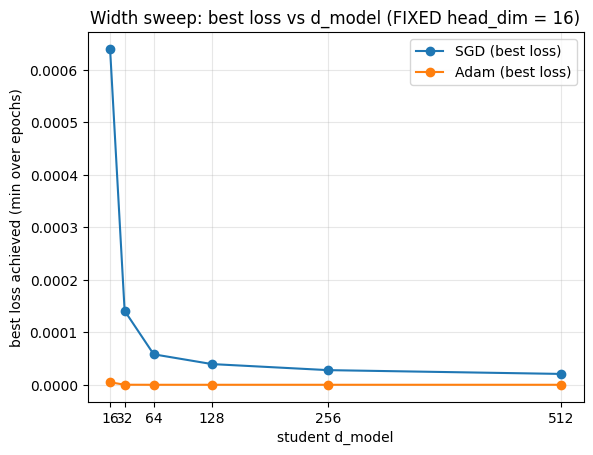

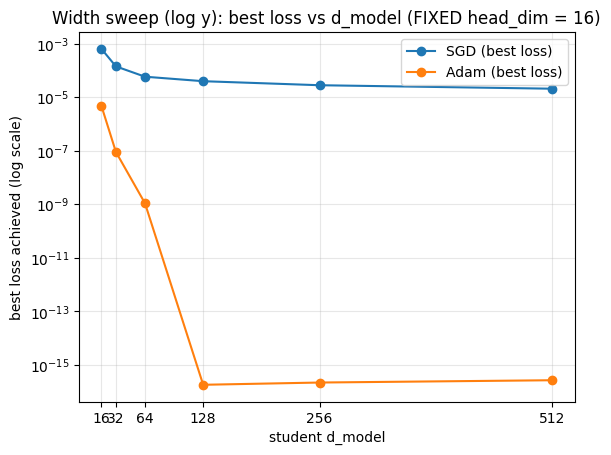

In [ ]:
results, example_curves = sweep_d_model_best_loss_constant_head_dim(
    N=2048,
    batch_size=2048,          # full batch
    seq_len=32,
    vocab_size=128,
    teacher_d_model=16,
    teacher_heads=2,
    teacher_d_ff=64,
    student_d_models=(16, 32, 64, 128, 256, 512),
    d_head=16,
    student_d_ff_factor=4,
    epochs=10000,
    lr_sgd=1e-2,
    lr_adam=1e-3,
    init_seeds=(123,),
)

## Plotting log loss plots

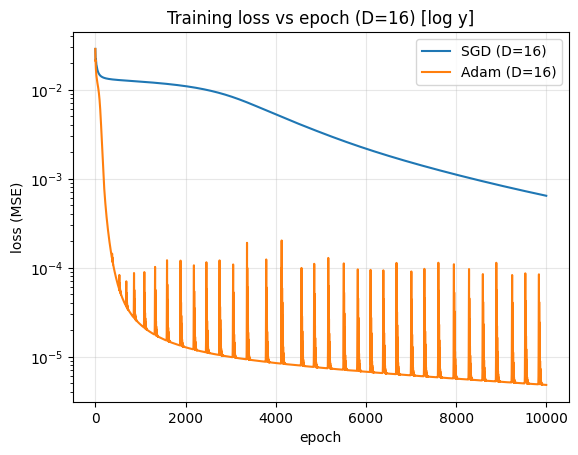

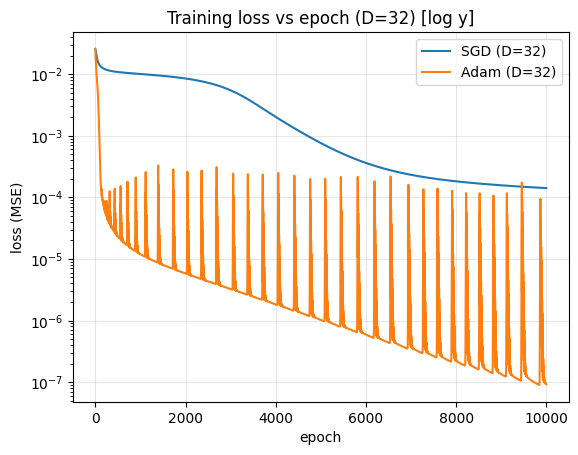

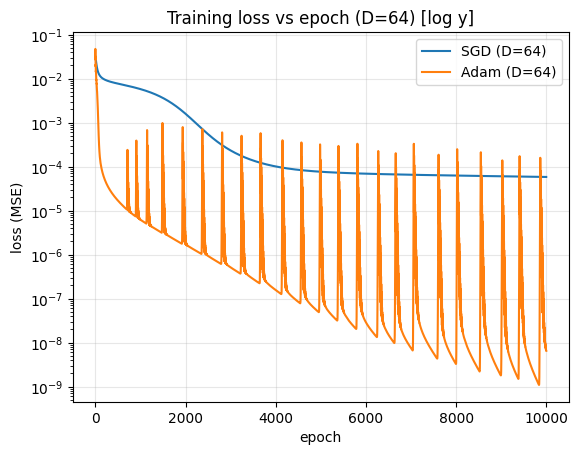

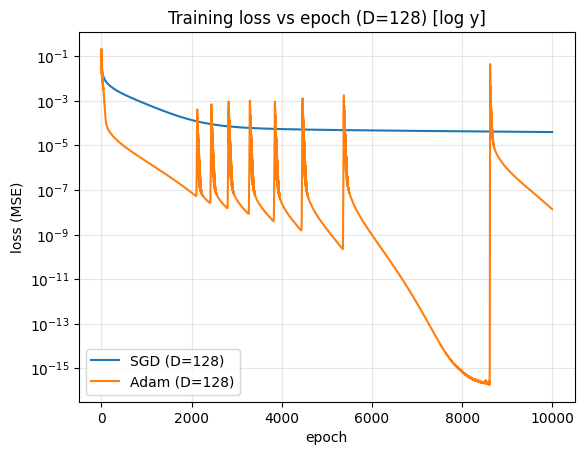

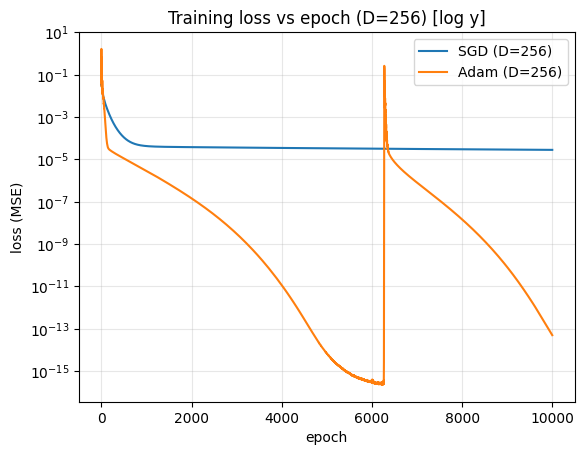

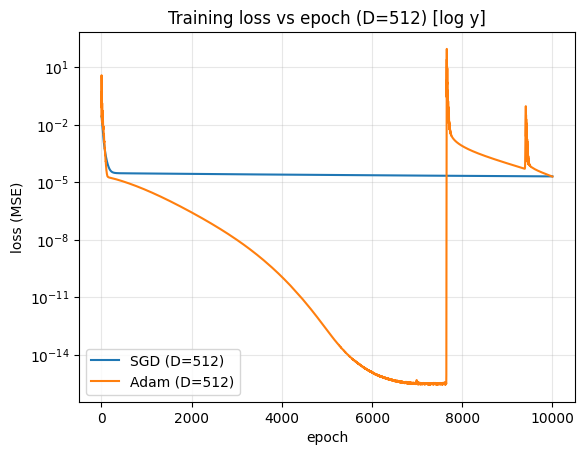

In [ ]:
def plot_training_curves(example_curves, Ds=(16, 32, 64, 128, 256, 512), logy=False):
    for D in Ds:
        if D not in example_curves["sgd"] or D not in example_curves["adam"]:
            continue
        plt.figure()
        plt.plot(example_curves["sgd"][D], label=f"SGD (D={D})")
        plt.plot(example_curves["adam"][D], label=f"Adam (D={D})")
        if logy:
            plt.yscale("log")
        plt.xlabel("epoch")
        plt.ylabel("loss (MSE)")
        plt.title(f"Training loss vs epoch (D={D})" + (" [log y]" if logy else ""))
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

# linear-y
#plot_training_curves(example_curves, Ds=(16, 32, 64, 128, 256, 512), logy=False)

# log-y (usually more informative)
plot_training_curves(example_curves, Ds=(16, 32, 64, 128, 256, 512), logy=True)

# Section 5 Case Study: Kernel ReLU Experiment

seed: 0
mode: theory
H0: 1.707270235842663
L_tilde_theory: 229052.8785731101
r_min_theory: 0.1711330409690392
r_max_theory: 18.4784752392759
A_theory: 18.4784752392759
C1: 2.954816244066372
W_bound: 0.6489570138148749
B: 18.4784752392759
theorem_bracket: 0.949
a_sup_theory: 8.286296211702871e-06
a_sup_used: 8.286296211702871e-06
final_F: 1.5874346330692517
final_H: 1.5880267866432607
final_grad_norm: 3.7776199143158684
min_theta_norm_over_run: 1.1640128492889776
max_theta_norm_over_run: 1.9854904672352593
max_abs_a_over_run: 1.3664634705496859
all_iterates_safe: True
all_segments_safe: True
all_steps_within_clip_bounds: True
min_alpha0_actual: 0.1206811794378873
max_local_smoothness_ratio: 11.795530607024912
max_local_smoothness_ratio_over_L: 5.149697607166269e-05
energy_violation_count: 0
max_energy_increase: 0.0


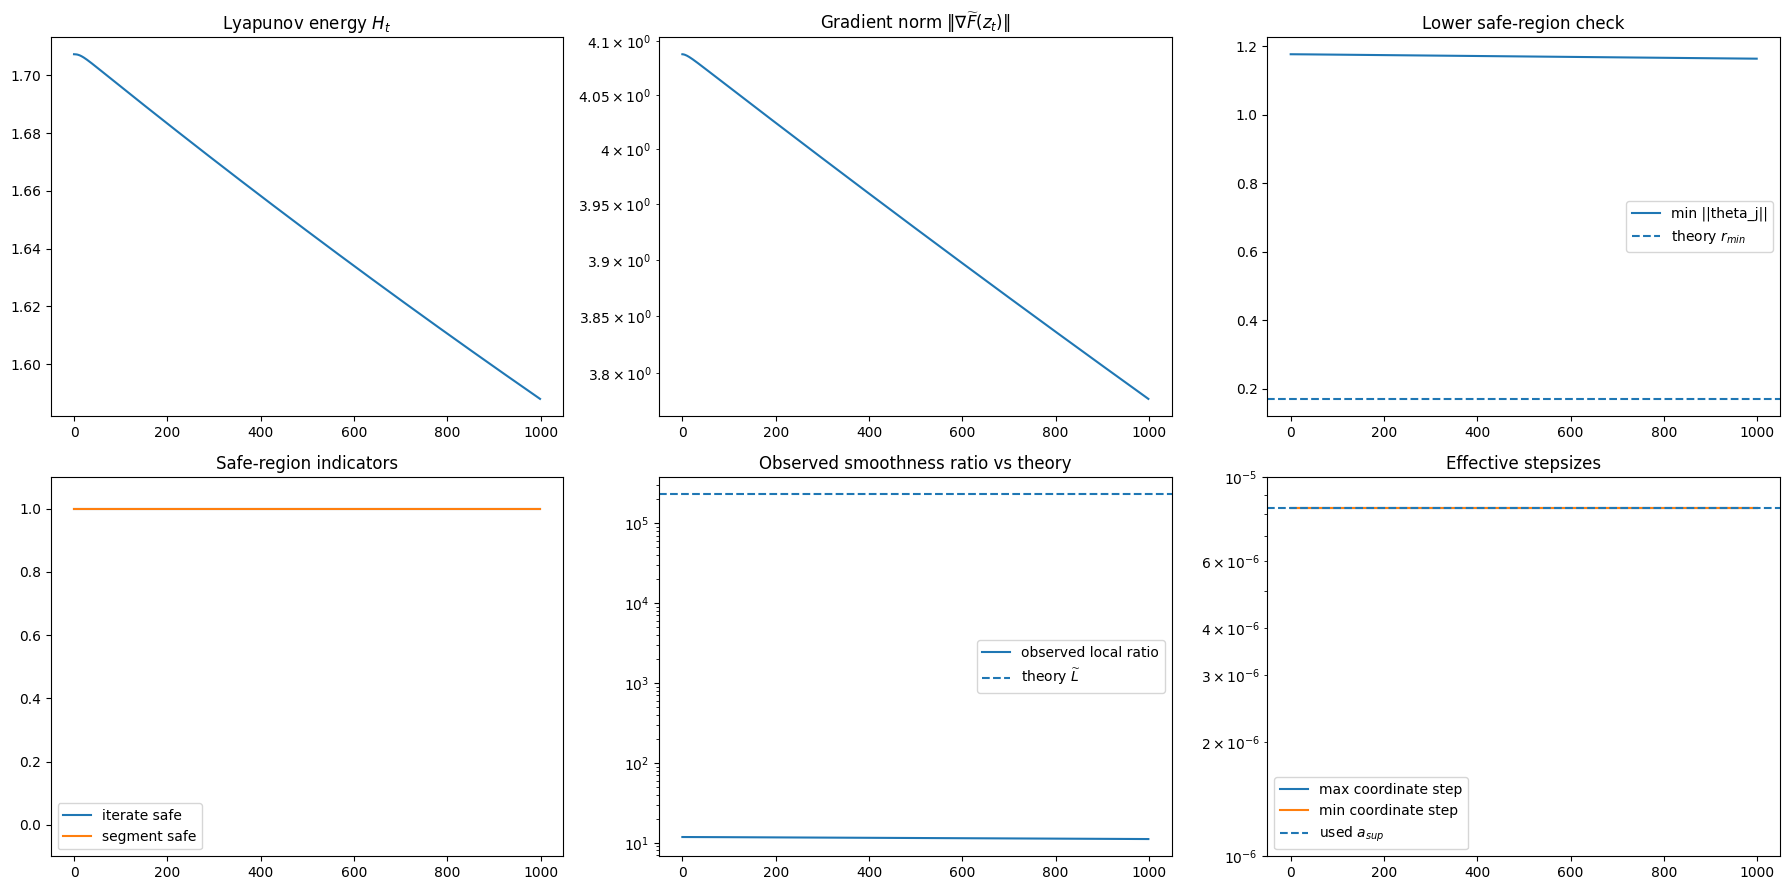

seed: 0
mode: manual
H0: 1.707270235842663
L_tilde_theory: 229052.8785731101
r_min_theory: 0.1711330409690392
r_max_theory: 18.4784752392759
A_theory: 18.4784752392759
C1: 2.954816244066372
W_bound: 0.6489570138148749
B: 18.4784752392759
theorem_bracket: 0.949
a_sup_theory: 8.286296211702871e-06
a_sup_used: 0.05
final_F: 0.22448185290663064
final_H: 0.22474353820714205
final_grad_norm: 0.031918744792522546
min_theta_norm_over_run: 0.8526088490198415
max_theta_norm_over_run: 1.985128962002912
max_abs_a_over_run: 1.3664634705496859
all_iterates_safe: True
all_segments_safe: True
all_steps_within_clip_bounds: True
min_alpha0_actual: 1.9999999999999998e-05
max_local_smoothness_ratio: 11.716793532038247
max_local_smoothness_ratio_over_L: 5.115322542562341e-05
energy_violation_count: 201
max_energy_increase: 0.00011182007424986873


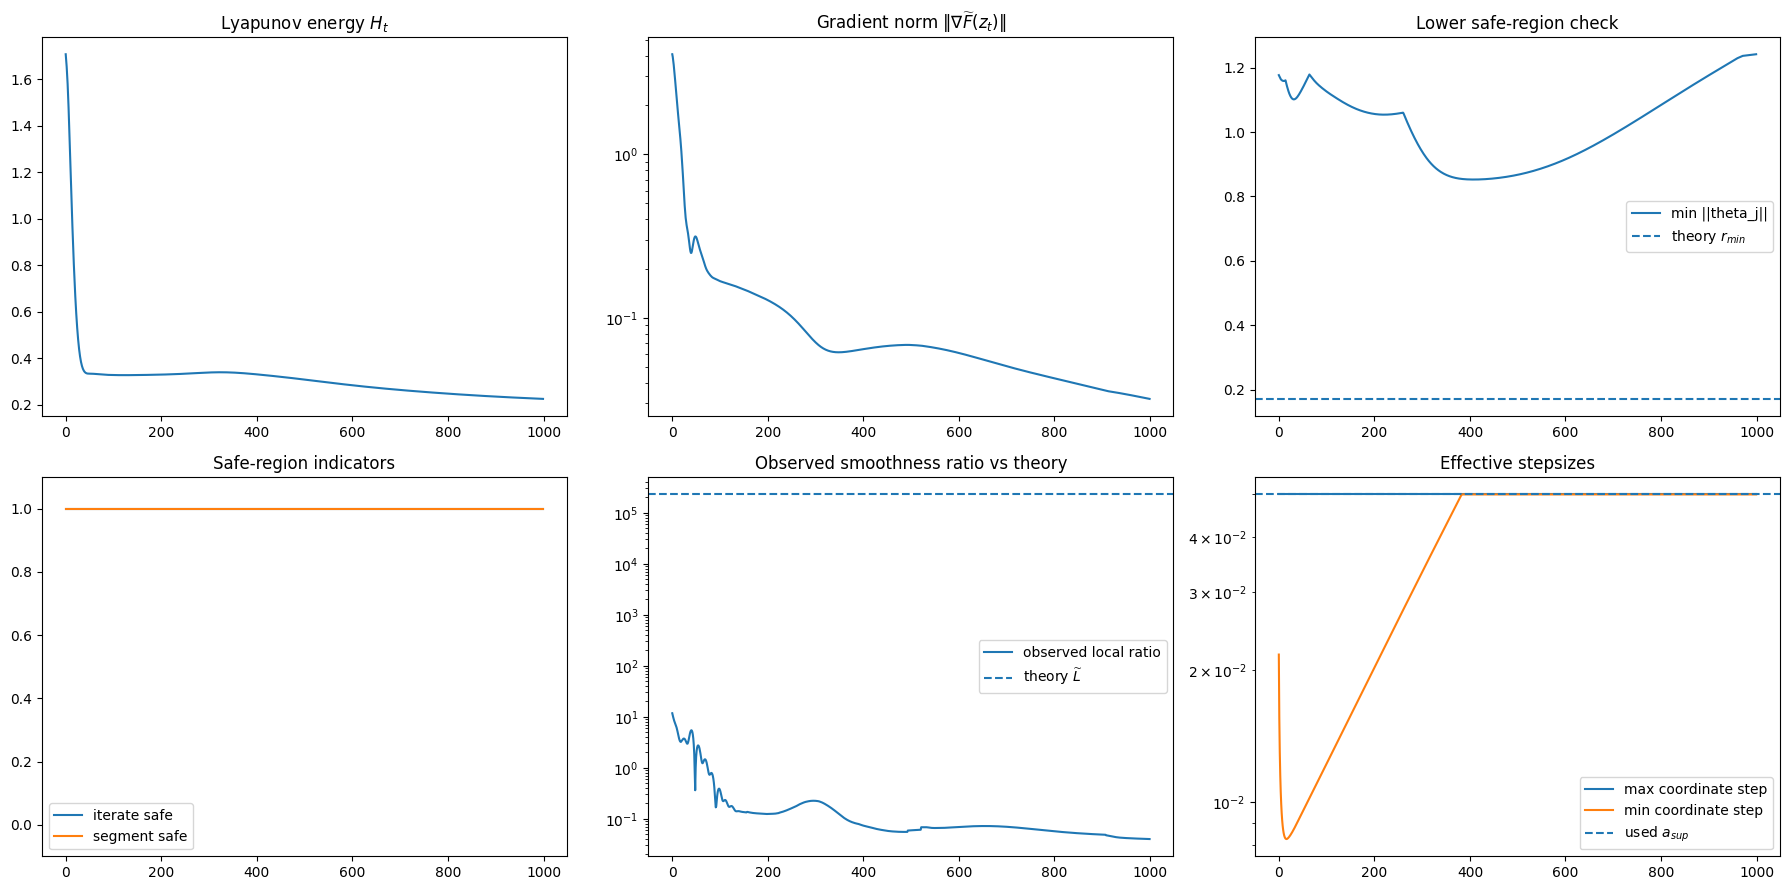

THEORY MODE
Across seeds:
Fraction with all iterates safe:        1.00
Fraction with all segments safe:        1.00
Fraction with no energy increase:       0.98
Fraction with all steps within bounds:  0.37
Median max(local ratio / L_tilde):      0.0000
Worst max(local ratio / L_tilde):       0.0003

MANUAL MODE
Across seeds:
Fraction with all iterates safe:        1.00
Fraction with all segments safe:        1.00
Fraction with no energy increase:       0.45
Fraction with all steps within bounds:  1.00
Median max(local ratio / L_tilde):      0.0000
Worst max(local ratio / L_tilde):       0.0003


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. RELU KERNEL AND DERIVATIVES
# =========================================================
def relu_kernel(u, v):
    ru = np.linalg.norm(u)
    rv = np.linalg.norm(v)
    if ru < 1e-12 or rv < 1e-12:
        return 0.0
    rho = np.clip(np.dot(u, v) / (ru * rv), -1.0, 1.0)
    phi = np.arccos(rho)
    sin_phi = np.sqrt(max(0.0, 1.0 - rho**2))
    return (ru * rv / (2.0 * np.pi)) * (sin_phi + (np.pi - phi) * rho)

def grad_relu_kernel_u(u, v):
    """
    Gradient with respect to the first argument u.
    For ReLU arc-cosine kernel:
        ∇_u K(u,v) = ((π - φ)/(2π)) v
    where φ = arccos(rho).
    """
    ru = np.linalg.norm(u)
    rv = np.linalg.norm(v)
    if ru < 1e-12 or rv < 1e-12:
        return np.zeros_like(u)
    rho = np.clip(np.dot(u, v) / (ru * rv), -1.0, 1.0)
    phi = np.arccos(rho)
    return ((np.pi - phi) / (2.0 * np.pi)) * v

def teacher_constant(W, c):
    r = W.shape[0]
    K_tt = np.empty((r, r))
    for l in range(r):
        for q in range(r):
            K_tt[l, q] = relu_kernel(W[l], W[q])
    return float(c @ K_tt @ c)

# =========================================================
# 2. OBJECTIVE, GRADIENTS, SAFE REGION, ENERGY
# =========================================================
def compute_matrices(theta, W):
    m = theta.shape[0]
    r = W.shape[0]
    K_ss = np.empty((m, m))
    K_st = np.empty((m, r))
    for j in range(m):
        for k in range(m):
            K_ss[j, k] = relu_kernel(theta[j], theta[k])
        for l in range(r):
            K_st[j, l] = relu_kernel(theta[j], W[l])
    return K_ss, K_st

def regularized_objective(a, theta, W, c, mu, lam, include_teacher_constant=True):
    K_ss, K_st = compute_matrices(theta, W)
    unreg = a @ K_ss @ a - 2.0 * a @ K_st @ c
    if include_teacher_constant:
        unreg += teacher_constant(W, c)
    theta_norm_sq = np.sum(theta**2, axis=1)
    reg = np.sum(mu / (theta_norm_sq + 1e-12) + lam * theta_norm_sq + lam * a**2)
    return float(unreg + reg)

def compute_gradients(a, theta, W, c, mu, lam):
    m, dim = theta.shape
    r = W.shape[0]

    K_ss, K_st = compute_matrices(theta, W)

    grad_a = np.zeros_like(a)
    grad_theta = np.zeros_like(theta)

    for j in range(m):
        grad_a[j] = (
            2.0 * np.sum(a * K_ss[j, :])
            - 2.0 * np.sum(c * K_st[j, :])
            + 2.0 * lam * a[j]
        )

        term1 = np.zeros(dim)
        for k in range(m):
            term1 += a[k] * grad_relu_kernel_u(theta[j], theta[k])
        term1 *= 2.0 * a[j]

        term2 = np.zeros(dim)
        for l in range(r):
            term2 += c[l] * grad_relu_kernel_u(theta[j], W[l])
        term2 *= 2.0 * a[j]

        norm_sq = np.dot(theta[j], theta[j])
        barrier_grad = -(2.0 * mu / (norm_sq + 1e-12)**2) * theta[j]
        quad_grad = 2.0 * lam * theta[j]

        grad_theta[j] = term1 - term2 + barrier_grad + quad_grad

    return grad_a, grad_theta

def flatten_state(a, theta):
    return np.concatenate([a.ravel(), theta.ravel()])

def flatten_grad(grad_a, grad_theta):
    return np.concatenate([grad_a.ravel(), grad_theta.ravel()])

def safe_region_bounds(H0, mu, lam):
    r_min = np.sqrt(mu / H0)
    r_max = np.sqrt(H0 / lam)
    A = np.sqrt(H0 / lam)
    return r_min, r_max, A

def check_iterate_safe_region(a, theta, r_min, r_max, A):
    theta_norms = np.linalg.norm(theta, axis=1)
    ok_a = np.all(np.abs(a) <= A + 1e-10)
    ok_low = np.all(theta_norms >= r_min - 1e-10)
    ok_high = np.all(theta_norms <= r_max + 1e-10)
    return ok_a and ok_low and ok_high

def min_norm_on_segment(x, y):
    """
    Compute min_{t in [0,1]} ||(1-t)x + ty|| exactly.
    """
    d = y - x
    dd = np.dot(d, d)
    if dd < 1e-16:
        return np.linalg.norm(x)
    t_star = -np.dot(x, d) / dd
    t_star = np.clip(t_star, 0.0, 1.0)
    z = x + t_star * d
    return np.linalg.norm(z)

def max_norm_on_segment(x, y):
    """
    For convex norm, max over a line segment is attained at an endpoint.
    """
    return max(np.linalg.norm(x), np.linalg.norm(y))

def check_segment_safe_region(a0, theta0, a1, theta1, r_min, r_max, A):
    a_seg_max = np.maximum(np.abs(a0), np.abs(a1))
    if np.any(a_seg_max > A + 1e-10):
        return False

    for j in range(theta0.shape[0]):
        mn = min_norm_on_segment(theta0[j], theta1[j])
        mx = max_norm_on_segment(theta0[j], theta1[j])
        if mn < r_min - 1e-10 or mx > r_max + 1e-10:
            return False
    return True

def lyapunov_energy(a, theta, p_a, p_theta, step_a, step_theta, W, c, mu, lam, beta1):
    F = regularized_objective(a, theta, W, c, mu, lam, include_teacher_constant=True)
    b = 1.0 - beta1
    kinetic = (1.0 / (2.0 * b)) * (
        np.sum(step_a * (p_a**2)) + np.sum(step_theta * (p_theta**2))
    )
    return F + kinetic

# =========================================================
# 3. EXPLICIT SMOOTHNESS CONSTANT FROM THE PROOF
# =========================================================
def explicit_smoothness_constant(H0, mu, lam, W, c, m):
    """
    Implements the proof-side bound:
        L_tilde =
            m r_max^2
            + 4 B ((m+1) A + C1)
            + (3 B / (pi r_min)) (m A^2 + A C1)
            + 4 lambda
            + 6 mu / r_min^4
    where
        r_min = sqrt(mu / H0)
        r_max = sqrt(H0 / lambda)
        A     = sqrt(H0 / lambda)
        C1    = sum |c_l|
        B     = max(r_max, W_bound)
    """
    r_min, r_max, A = safe_region_bounds(H0, mu, lam)
    W_bound = float(np.max(np.linalg.norm(W, axis=1))) if len(W) else 0.0
    C1 = float(np.sum(np.abs(c)))
    B = max(r_max, W_bound)

    L_tilde = (
        m * (r_max**2)
        + 4.0 * B * ((m + 1) * A + C1)
        + (3.0 * B / (np.pi * r_min)) * (m * (A**2) + A * C1)
        + 4.0 * lam
        + 6.0 * mu / (r_min**4)
    )
    return {
        "L_tilde": L_tilde,
        "r_min": r_min,
        "r_max": r_max,
        "A": A,
        "C1": C1,
        "W_bound": W_bound,
        "B": B,
    }

def theorem_asup(L_tilde, beta1, alpha0=1.0, eps_margin=1e-3):
    """
    Proof-side admissible upper clip:
        a_sup <= (2/L) * ( 1 - ((b-(1-alpha0))^2)/(2 b alpha0) - (1-alpha0)/(2b) - eps_margin )
    with b = 1 - beta1.
    Returns 0 if the bracket is not positive.
    """
    b = 1.0 - beta1
    bracket = 1.0 - ((b - (1.0 - alpha0))**2) / (2.0 * b * alpha0) - (1.0 - alpha0) / (2.0 * b) - eps_margin
    if bracket <= 0.0:
        return 0.0, bracket
    return (2.0 / L_tilde) * bracket, bracket

def growth_ratio_alpha0(step_prev, step_next, tol=1e-15):
    """
    Smallest alpha0 in (0,1] such that step_next <= step_prev / alpha0 coordinatewise.
    Equivalently alpha0 <= step_prev / step_next for all coordinates, so
        alpha0_actual = min_i step_prev_i / step_next_i, clipped to <= 1.
    """
    x = np.concatenate([step_prev.ravel(), step_next.ravel()])
    if np.any(x <= 0):
        return 0.0
    ratios = step_prev.ravel() / np.maximum(step_next.ravel(), tol)
    alpha0_actual = float(np.min(ratios))
    return min(1.0, alpha0_actual)

# =========================================================
# 4. NUMERICAL LOCAL SMOOTHNESS CHECK
# =========================================================
def numerical_local_smoothness_ratio(a0, theta0, a1, theta1, W, c, mu, lam):
    """
    Estimate
        ||∇F(z1) - ∇F(z0)|| / ||z1 - z0||
    which should be <= L_tilde if both points and the segment lie in the safe region.
    """
    g0a, g0t = compute_gradients(a0, theta0, W, c, mu, lam)
    g1a, g1t = compute_gradients(a1, theta1, W, c, mu, lam)

    dz = np.concatenate([(a1 - a0).ravel(), (theta1 - theta0).ravel()])
    dg = np.concatenate([(g1a - g0a).ravel(), (g1t - g0t).ravel()])

    ndz = np.linalg.norm(dz)
    if ndz < 1e-16:
        return 0.0
    return float(np.linalg.norm(dg) / ndz)

# =========================================================
# 5. SINGLE RUN
# =========================================================
def run_experiment(
    seed=0,
    m=6,
    r=3,
    dim=2,
    mu=0.05,
    lam=0.005,
    beta1=0.9,
    beta2=0.99,
    alpha=0.005,
    delta=1e-6,
    a_sup_mode="theory",   # "theory" or "manual"
    a_sup_manual=0.05,
    alpha0_for_theory=1.0,
    eps_margin=1e-3,
    eps=1e-8,
    iterations=1000,
    init_theta_scale=0.4,
    init_theta_shift=1.2,
):
    rng = np.random.default_rng(seed)

    W = rng.standard_normal((r, dim))
    c = rng.standard_normal(r)

    theta = rng.standard_normal((m, dim)) * init_theta_scale + init_theta_shift
    a = rng.standard_normal(m)

    p_a = np.zeros_like(a)
    p_theta = np.zeros_like(theta)
    v_a = np.zeros_like(a)
    v_theta = np.zeros_like(theta)

    step_a = np.full_like(a, delta)
    step_theta = np.full_like(theta, delta)

    # Initial energy and proof-side constants
    H0 = lyapunov_energy(a, theta, p_a, p_theta, step_a, step_theta, W, c, mu, lam, beta1)
    theory = explicit_smoothness_constant(H0, mu, lam, W, c, m)
    L_tilde = theory["L_tilde"]
    r_min = theory["r_min"]
    r_max = theory["r_max"]
    A = theory["A"]
    asup_theory, theorem_bracket = theorem_asup(
        L_tilde=L_tilde,
        beta1=beta1,
        alpha0=alpha0_for_theory,
        eps_margin=eps_margin,
    )

    if a_sup_mode == "theory":
        if asup_theory <= 0:
            raise ValueError("The theorem-based a_sup is non-positive. Adjust beta1 / alpha0 / eps_margin.")
        a_sup = asup_theory
    elif a_sup_mode == "manual":
        a_sup = a_sup_manual
    else:
        raise ValueError("a_sup_mode must be 'theory' or 'manual'.")

    history = {
        "F": [],
        "H": [],
        "grad_norm": [],
        "min_theta_norm": [],
        "max_theta_norm": [],
        "max_abs_a": [],
        "iterate_safe": [],
        "segment_safe": [],
        "local_smoothness_ratio": [],
        "step_max": [],
        "step_min": [],
        "theory_step_ok": [],
        "alpha0_actual": [],
        "max_energy_increase": 0.0,
        "energy_violation_count": 0,
    }

    prev_full_step = np.concatenate([step_a.ravel(), step_theta.ravel()])

    for t in range(iterations):
        grad_a, grad_theta = compute_gradients(a, theta, W, c, mu, lam)
        gnorm = np.sqrt(np.sum(grad_a**2) + np.sum(grad_theta**2))
        F = regularized_objective(a, theta, W, c, mu, lam)
        H = lyapunov_energy(a, theta, p_a, p_theta, step_a, step_theta, W, c, mu, lam, beta1)

        theta_norms = np.linalg.norm(theta, axis=1)

        history["F"].append(F)
        history["H"].append(H)
        history["grad_norm"].append(gnorm)
        history["min_theta_norm"].append(np.min(theta_norms))
        history["max_theta_norm"].append(np.max(theta_norms))
        history["max_abs_a"].append(np.max(np.abs(a)))
        history["iterate_safe"].append(check_iterate_safe_region(a, theta, r_min, r_max, A))

        # Adam first/second moment
        p_a = beta1 * p_a + (1.0 - beta1) * grad_a
        p_theta = beta1 * p_theta + (1.0 - beta1) * grad_theta

        v_a = beta2 * v_a + (1.0 - beta2) * (grad_a**2)
        v_theta = beta2 * v_theta + (1.0 - beta2) * (grad_theta**2)

        next_step_a = np.clip(alpha / (np.sqrt(v_a) + eps), delta, a_sup)
        next_step_theta = np.clip(alpha / (np.sqrt(v_theta) + eps), delta, a_sup)

        a_next = a - next_step_a * p_a
        theta_next = theta - next_step_theta * p_theta

        seg_ok = check_segment_safe_region(a, theta, a_next, theta_next, r_min, r_max, A)
        history["segment_safe"].append(seg_ok)

        # numerical local smoothness ratio
        ratio = numerical_local_smoothness_ratio(a, theta, a_next, theta_next, W, c, mu, lam)
        history["local_smoothness_ratio"].append(ratio)

        # theorem-side step-size checks
        current_full_step = np.concatenate([next_step_a.ravel(), next_step_theta.ravel()])
        alpha0_actual = growth_ratio_alpha0(prev_full_step, current_full_step)
        theory_step_ok = np.all(current_full_step <= a_sup + 1e-12) and np.all(current_full_step >= delta - 1e-12)

        history["alpha0_actual"].append(alpha0_actual)
        history["theory_step_ok"].append(theory_step_ok)
        history["step_max"].append(float(np.max(current_full_step)))
        history["step_min"].append(float(np.min(current_full_step)))

        prev_full_step = current_full_step.copy()

        # Move to next iterate
        a, theta = a_next, theta_next
        step_a, step_theta = next_step_a, next_step_theta

    # Post-process energy monotonicity
    H_arr = np.array(history["H"])
    dH = np.diff(H_arr)
    pos = dH[dH > 1e-10]
    history["max_energy_increase"] = float(np.max(pos)) if len(pos) else 0.0
    history["energy_violation_count"] = int(np.sum(dH > 1e-10))

    local_ratios = np.array(history["local_smoothness_ratio"])
    alpha0_actuals = np.array(history["alpha0_actual"])

    summary = {
        "seed": seed,
        "mode": a_sup_mode,
        "H0": float(H0),
        "L_tilde_theory": float(L_tilde),
        "r_min_theory": float(r_min),
        "r_max_theory": float(r_max),
        "A_theory": float(A),
        "C1": float(theory["C1"]),
        "W_bound": float(theory["W_bound"]),
        "B": float(theory["B"]),
        "theorem_bracket": float(theorem_bracket),
        "a_sup_theory": float(asup_theory),
        "a_sup_used": float(a_sup),
        "final_F": float(history["F"][-1]),
        "final_H": float(history["H"][-1]),
        "final_grad_norm": float(history["grad_norm"][-1]),
        "min_theta_norm_over_run": float(np.min(history["min_theta_norm"])),
        "max_theta_norm_over_run": float(np.max(history["max_theta_norm"])),
        "max_abs_a_over_run": float(np.max(history["max_abs_a"])),
        "all_iterates_safe": bool(np.all(history["iterate_safe"])),
        "all_segments_safe": bool(np.all(history["segment_safe"])),
        "all_steps_within_clip_bounds": bool(np.all(history["theory_step_ok"])),
        "min_alpha0_actual": float(np.min(alpha0_actuals)) if len(alpha0_actuals) else 1.0,
        "max_local_smoothness_ratio": float(np.max(local_ratios)) if len(local_ratios) else 0.0,
        "max_local_smoothness_ratio_over_L": float(np.max(local_ratios) / L_tilde) if len(local_ratios) else 0.0,
        "energy_violation_count": history["energy_violation_count"],
        "max_energy_increase": history["max_energy_increase"],
    }

    return history, summary

# =========================================================
# 6. MULTI-SEED STUDY
# =========================================================
def run_multi_seed_study(seeds=range(100), **kwargs):
    histories = []
    summaries = []
    for seed in seeds:
        hist, summ = run_experiment(seed=seed, **kwargs)
        histories.append(hist)
        summaries.append(summ)
    return histories, summaries

# =========================================================
# 7. PRINTING / PLOTTING
# =========================================================
def print_summary(summary):
    print("=" * 70)
    for k, v in summary.items():
        print(f"{k}: {v}")
    print("=" * 70)

def plot_single_run(history, summary):
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))

    # H_t
    axes[0, 0].plot(history["H"])
    axes[0, 0].set_title("Lyapunov energy $H_t$")

    # gradient norm
    axes[0, 1].plot(history["grad_norm"])
    axes[0, 1].set_yscale("log")
    axes[0, 1].set_title(r"Gradient norm $\|\nabla \widetilde F(z_t)\|$")

    # safe region lower bound
    axes[0, 2].plot(history["min_theta_norm"], label="min ||theta_j||")
    axes[0, 2].axhline(summary["r_min_theory"], linestyle="--", label="theory $r_{min}$")
    axes[0, 2].set_title("Lower safe-region check")
    axes[0, 2].legend()

    # safe indicators
    axes[1, 0].plot(np.array(history["iterate_safe"], dtype=int), label="iterate safe")
    axes[1, 0].plot(np.array(history["segment_safe"], dtype=int), label="segment safe")
    axes[1, 0].set_ylim(-0.1, 1.1)
    axes[1, 0].set_title("Safe-region indicators")
    axes[1, 0].legend()

    # local smoothness ratio versus theory L
    axes[1, 1].plot(history["local_smoothness_ratio"], label="observed local ratio")
    axes[1, 1].axhline(summary["L_tilde_theory"], linestyle="--", label="theory $\\widetilde L$")
    axes[1, 1].set_yscale("log")
    axes[1, 1].set_title("Observed smoothness ratio vs theory")
    axes[1, 1].legend()

    # step size diagnostics
    axes[1, 2].plot(history["step_max"], label="max coordinate step")
    axes[1, 2].plot(history["step_min"], label="min coordinate step")
    axes[1, 2].axhline(summary["a_sup_used"], linestyle="--", label="used $a_{sup}$")
    axes[1, 2].set_yscale("log")
    axes[1, 2].set_title("Effective stepsizes")
    axes[1, 2].legend()

    plt.tight_layout()
    plt.show()

def print_multi_seed_summary(summaries):
    safe_iter_frac = np.mean([s["all_iterates_safe"] for s in summaries])
    safe_seg_frac = np.mean([s["all_segments_safe"] for s in summaries])
    energy_ok_frac = np.mean([s["energy_violation_count"] == 0 for s in summaries])
    step_ok_frac = np.mean([s["all_steps_within_clip_bounds"] for s in summaries])

    max_ratio_over_L = np.max([s["max_local_smoothness_ratio_over_L"] for s in summaries])
    med_ratio_over_L = np.median([s["max_local_smoothness_ratio_over_L"] for s in summaries])

    print("Across seeds:")
    print(f"Fraction with all iterates safe:        {safe_iter_frac:.2f}")
    print(f"Fraction with all segments safe:        {safe_seg_frac:.2f}")
    print(f"Fraction with no energy increase:       {energy_ok_frac:.2f}")
    print(f"Fraction with all steps within bounds:  {step_ok_frac:.2f}")
    print(f"Median max(local ratio / L_tilde):      {med_ratio_over_L:.4f}")
    print(f"Worst max(local ratio / L_tilde):       {max_ratio_over_L:.4f}")

# =========================================================
# 8. EXAMPLE USAGE
# =========================================================

# -----------------------------------------------------
# A. Theory-respecting run
# -----------------------------------------------------
hist, summ = run_experiment(
    seed=0,
    a_sup_mode="theory",     # use theorem-derived a_sup
    alpha0_for_theory=1.0,   # easiest clean case
    eps_margin=1e-3,
    iterations=1000,
)
print_summary(summ)
plot_single_run(hist, summ)

# -----------------------------------------------------
# B. Compare against old manual clip regime
# -----------------------------------------------------
hist2, summ2 = run_experiment(
    seed=0,
    a_sup_mode="manual",
    a_sup_manual=0.05,
    iterations=1000,
)
print_summary(summ2)
plot_single_run(hist2, summ2)

# -----------------------------------------------------
# C. Multi-seed study in theorem regime
# -----------------------------------------------------

# Multi-seed study: theory mode
_, summaries_theory = run_multi_seed_study(
    seeds=range(100),
    a_sup_mode="theory",
    alpha0_for_theory=1.0,
    eps_margin=1e-3,
    iterations=1000,
)
print("THEORY MODE")
print_multi_seed_summary(summaries_theory)


# Multi-seed study: manual mode

_, summaries_manual = run_multi_seed_study(
    seeds=range(100),
    a_sup_mode="manual",
    a_sup_manual=0.05,
    iterations=1000,
)
print("\nMANUAL MODE")
print_multi_seed_summary(summaries_manual)

## Additional check for significance of energy violation

In [ ]:
worst_theory = max(summaries_theory, key=lambda s: s["max_energy_increase"])
worst_manual = max(summaries_manual, key=lambda s: s["max_energy_increase"])

print("Worst theory-mode seed:")
print(f"seed = {worst_theory['seed']}, max_energy_increase = {worst_theory['max_energy_increase']:.12f}")

print("Worst manual-mode seed:")
print(f"seed = {worst_manual['seed']}, max_energy_increase = {worst_manual['max_energy_increase']:.12f}")

Worst theory-mode seed:
seed = 79, max_energy_increase = 0.000004119791
Worst manual-mode seed:
seed = 22, max_energy_increase = 0.001990888831


# Section 6 AdamQ

## Defining AdamQ

In [ ]:
import math
import torch
from torch.optim.optimizer import Optimizer

class AdamQ(Optimizer):
    """
    Adam with generalized denominator power:
        step = lr * m_hat / ( (v_hat)^{q} + eps )

    Standard Adam corresponds to q = 0.5.

    Args:
      params: iterable of parameters
      lr: learning rate
      betas: (beta1, beta2)
      eps: epsilon
      q: exponent on v (default 0.5 => standard Adam)
      weight_decay: decoupled weight decay (AdamW-style) if decoupled_wd=True, else classic L2
      decoupled_wd: if True, apply AdamW-style decay
    """
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8,
                 q=0.5, weight_decay=0.0, decoupled_wd=True):
        if lr <= 0.0:
            raise ValueError("lr must be > 0")
        if not (0.0 <= eps):
            raise ValueError("eps must be >= 0")
        b1, b2 = betas
        if not (0.0 <= b1 < 1.0 and 0.0 <= b2 < 1.0):
            raise ValueError("betas must be in [0,1)")
        if q <= 0.0:
            raise ValueError("q must be > 0")

        defaults = dict(lr=lr, betas=betas, eps=eps, q=q,
                        weight_decay=weight_decay, decoupled_wd=decoupled_wd)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            beta1, beta2 = group["betas"]
            eps = group["eps"]
            q = group["q"]
            wd = group["weight_decay"]
            decoupled = group["decoupled_wd"]

            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad

                if g.is_sparse:
                    raise RuntimeError("AdamQ does not support sparse grads")

                state = self.state[p]
                if len(state) == 0:
                    state["step"] = 0
                    state["m"] = torch.zeros_like(p)
                    state["v"] = torch.zeros_like(p)

                m, v = state["m"], state["v"]
                state["step"] += 1
                t = state["step"]

                # Optional weight decay
                if wd != 0.0:
                    if decoupled:
                        # AdamW-style
                        p.mul_(1.0 - lr * wd)
                    else:
                        # classic L2
                        g = g.add(p, alpha=wd)

                # Update moments
                m.mul_(beta1).add_(g, alpha=1 - beta1)
                v.mul_(beta2).addcmul_(g, g, value=1 - beta2)

                # Bias correction
                m_hat = m / (1 - beta1 ** t)
                v_hat = v / (1 - beta2 ** t)

                denom = v_hat.pow(q).add_(eps)
                p.addcdiv_(m_hat, denom, value=-lr)

        return loss

def make_adamq(model, lr=1e-3, q=0.5, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.0):
    return AdamQ(model.parameters(), lr=lr, q=q, betas=betas, eps=eps, weight_decay=weight_decay)

## Experiment

/tmp/ipykernel_3160/1980185019.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=1)


                  Adam (q=0.5) | final 5.698e-09 | best 1.929e-16
                 AdamQ (q=1.0) | final 1.131e-02 | best 3.410e-15
                AdamQ (q=0.25) | final 9.511e-07 | best 9.511e-07
                 AdamQ (q=2.0) | final 1.611e+02 | best 1.097e-05
                 AdamQ (q=3.0) | final 1.189e-02 | best 1.347e-03


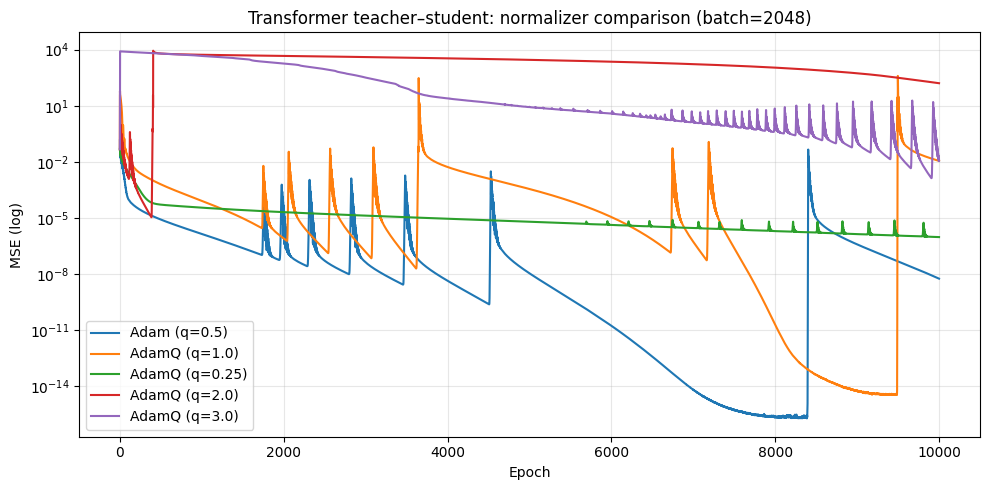

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Data + teacher (transformer)
# --------------------------
set_seed(0)
X, y, _teacher = make_teacher_student_dataset_transformer(
    N=2048,
    seq_len=32,
    vocab_size=128,
    teacher_d_model=16,
    teacher_heads=2,
    teacher_d_ff=64,
    noise_std=0.0,
    seed=0
)

# --------------------------
# Student model (bigger than teacher)
# --------------------------
make_model = lambda: OneLayerTransformerRegressor(
    vocab_size=128,
    seq_len=32,
    d_model=128,
    n_heads=8,
    d_ff=512,
    dropout=0.0
)

EPOCHS = 10000
BATCH  = 2048      # Full batch
seed_init = 999

# --------------------------
# Normalizer variants to compare
# NOTE: LR needs tuning per method
# --------------------------
optimizers = {
    "Adam (q=0.5)": lambda m: make_adamq(m, lr=1e-3, q=0.5, eps=1e-8),
    "AdamQ (q=1.0)": lambda m: make_adamq(m, lr=1e-5, q=1.0, eps=1e-8),
    "AdamQ (q=0.25)": lambda m: make_adamq(m, lr=1e-2, q=0.25, eps=1e-8),
    "AdamQ (q=2.0)": lambda m: make_adamq(m, lr=1e-7, q=2.0, eps=1e-8),
    "AdamQ (q=3.0)": lambda m: make_adamq(m, lr=1e-7, q=3.0, eps=1e-8)
}

# --------------------------
# Run + plot
# --------------------------
results = {}
plt.figure(figsize=(10, 5))

for name, make_opt in optimizers.items():
    losses = train_curve(
        X, y,
        make_model=make_model,
        make_optimizer=make_opt,
        epochs=EPOCHS,
        batch_size=BATCH,
        seed_for_init=seed_init,
        verbose=False
    )
    results[name] = losses
    print(f"{name:>30} | final {losses[-1]:.3e} | best {min(losses):.3e}")
    plt.plot(losses, label=name)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE (log)")
plt.title(f"Transformer teacher–student: normalizer comparison (batch={BATCH})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()